In [13]:
import numpy as np, pandas as pd
from sklearn.model_selection import GroupShuffleSplit

BASE = "/kaggle/input/competitions/shopee-product-matching"
df = pd.read_csv(f"{BASE}/train.csv")
SEED = 42

In [14]:
df.head()

,posting_id,image,image_phash,title,label_group
0,train_129225211,0000a68812bc7e98c42888dfb1c07da0.jpg,94974f937d4c2433,Paper Bag Victoria Secret,249114794
1,train_3386243561,00039780dfc94d01db8676fe789ecd05.jpg,af3f9460c2838f0f,"Double Tape 3M VHB 12 mm x 4,5 m ORIGINAL / DO...",2937985045
2,train_2288590299,000a190fdd715a2a36faed16e2c65df7.jpg,b94cb00ed3e50f78,Maling TTS Canned Pork Luncheon Meat 397 gr,2395904891
3,train_2406599165,00117e4fc239b1b641ff08340b429633.jpg,8514fc58eafea283,Daster Batik Lengan pendek - Motif Acak / Camp...,4093212188
4,train_3369186413,00136d1cf4edede0203f32f05f660588.jpg,a6f319f924ad708c,Nescafe \xc3\x89clair Latte 220ml,3648931069


In [15]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
train_i, rest_i = next(gss.split(df, groups=df.label_group))
train = df.iloc[train_i].reset_index(drop=True)
rest = df.iloc[rest_i]

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
val_i, test_i = next(gss2.split(rest, groups=rest.label_group))
val = rest.iloc[val_i].reset_index(drop=True)
test = rest.iloc[test_i].reset_index(drop=True)

for name, d in [("train", train), ("val", val), ("test", test)]:
    print(name, len(d), d.label_group.nunique())
assert not set(val.label_group) & set(test.label_group)
assert not set(train.label_group) & set(val.label_group)

train 23724 7709
val 5115 1652
test 5411 1653


## Train / validation / test split

I split `train.csv` by `label_group`, not by row, using
`GroupShuffleSplit` with seed 42 (70% / 15% / 15% of groups).

**Why by group.** [Your reason: the real test set holds groups never
seen in training, and a row-level split would put listings of the
same product on both sides and inflate the score.]

| Split | Listings | Groups |
|---|---|---|
| train | 23,724 | 7,709 |
| val | 5,115 | 1,652 |
| test | 5,411 | 1,653 |

Totals match the full data (34,250 listings, 11,014 groups), and
assertions confirm no group appears in more than one split.


**A caveat.** Group shares are exact but listing shares are not
(69.3 / 14.9 / 15.8%), because group sizes differ. Test has slightly
more listings per group (about 3.27 vs 3.10 for val), so the two
splits may not be equally hard. [I have not checked why.]

In [16]:
def set_f1(pred_sets, labels):
    labels = np.asarray(labels)
    counts = pd.Series(labels).value_counts()
    sizes = pd.Series(labels).map(counts).values
    f1 = np.empty(len(labels))
    for i, P in enumerate(pred_sets):
        P = np.asarray(P)
        inter = (labels[P] == labels[i]).sum()
        f1[i] = 2 * inter / (len(P) + sizes[i])
    return f1.mean()

lab = val.label_group.values
n = len(lab)
g = pd.Series(lab).map(pd.Series(lab).value_counts()).values

self_only = [[i] for i in range(n)]
perfect = [np.where(lab == lab[i])[0] for i in range(n)]
everything = [np.arange(n)] * n

print("self-only :", set_f1(self_only, lab), "| formula:", (2/(g+1)).mean())
print("perfect   :", set_f1(perfect, lab))
print("everything:", set_f1(everything, lab))

self-only : 0.46291637869376523 | formula: 0.46291637869376523
perfect   : 1.0
everything: 0.0020698683846940126


## Evaluation metric

Mean set-based F1. For each listing I compare the set of listings I
predict as matches (including itself) with its true group:
F1 = 2·|P ∩ T| / (|P| + |T|), then average over all listings.

**Why F1 and not accuracy.** nearly all pairs are
non-matches, so accuracy would be high for a model that finds
nothing. F1 penalises both missed matches and false matches . Since F1 score is the harmonic mean of precision and recall , it considers both of them which makes it better 

**Sanity checks on val**

| Baseline | Mean set-F1 |
|---|---|
| Predict everything | 0.0021 |
| Self only (floor) | 0.4629 |
| Perfect | 1.0000 |

The self-only score matches the formula mean(2 / (g + 1)). [Why the
floor is so high: 63% of groups are pairs, so predicting only
yourself already gets about half the credit.]

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

vec = TfidfVectorizer(lowercase=True)
vec.fit(train.title)                 
Xv = vec.transform(val.title)

S = cosine_similarity(Xv)            
np.fill_diagonal(S, 1.0)             
print(S.shape)

(5115, 5115)


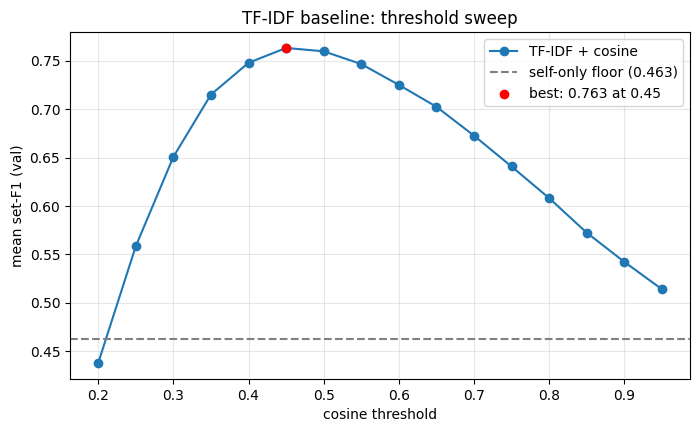

In [18]:
import os
import matplotlib.pyplot as plt

thr, f1 = zip(*results)
best_thr, best_f1 = max(results, key=lambda r: r[1])

plt.figure(figsize=(8, 4.5))
plt.plot(thr, f1, marker="o", label="TF-IDF + cosine")
plt.axhline(0.4629, color="gray", linestyle="--", label="self-only floor (0.463)")
plt.scatter([best_thr], [best_f1], color="red", zorder=3,
            label=f"best: {best_f1:.3f} at {best_thr}")
plt.xlabel("cosine threshold")
plt.ylabel("mean set-F1 (val)")
plt.title("TF-IDF baseline: threshold sweep")
plt.legend()
plt.grid(alpha=0.3)

os.makedirs("/kaggle/working/results", exist_ok=True)
plt.savefig("/kaggle/working/results/tfidf_threshold_sweep.png",
            dpi=150, bbox_inches="tight")
plt.show()

## Baseline: TF-IDF + cosine similarity

TF-IDF on titles, fitted on the train split only, cosine similarity
between every pair of val listings, and a threshold to decide matches.

| Threshold | Mean set-F1 (val) |
|---|---|
| 0.20 | 0.4378 |
| 0.45 (best) | 0.7632 |
| 0.95 | 0.5140 |

- Best threshold 0.45, F1 0.7632, against a floor of 0.4629.
- Too many titles clear the bar, so predicted sets are large and full of wrong listings. Precision collapses, and the score ends up worse than predicting nothing. This is the "everything" failure in miniature.
- Only near-identical titles pass, so predicted sets shrink toward "just me". It stays a little above 0.4629 because exact-duplicate titles still link.
- The peak isn't sharp, so any choice in this range is nearly as good, and the final number isn't fragile to the exact threshold.

In [19]:
i = 0
top = np.argsort(-S[i])[:5]
print(val.title[i])
for j in top:
    print(round(S[i, j], 2), val.title[j])

Double Tape 3M VHB 12 mm x 4,5 m ORIGINAL / DOUBLE FOAM TAPE
1.0 Double Tape 3M VHB 12 mm x 4,5 m ORIGINAL / DOUBLE FOAM TAPE
0.69 DOUBLE TAPE BUSA 3M Pe Foam Tape 24mm x 4M ORIGINAL
0.69 DOUBLE TAPE BUSA 3M Pe Foam Tape 24mm x 4M ORIGINAL
0.69 DOUBLE TAPE BUSA 3M Pe Foam Tape 24mm x 4M ORIGINAL
0.63 Double Tip / Double Sided Tape Perekat 2 Sisi Joyko 6 mm x 15 yard Double Tape


In [20]:
def predict(S, thr):
    return [np.where(S[i] >= thr)[0] for i in range(len(S))]

results = []
for thr in np.arange(0.2, 0.96, 0.05):
    results.append((round(thr, 2), set_f1(predict(S, thr), lab)))

for thr, f in results:
    print(thr, round(f, 4))

0.2 0.4378
0.25 0.5584
0.3 0.6507
0.35 0.715
0.4 0.7479
0.45 0.7632
0.5 0.7597
0.55 0.7466
0.6 0.7251
0.65 0.7025
0.7 0.6726
0.75 0.6408
0.8 0.6081
0.85 0.5724
0.9 0.5423
0.95 0.514
